<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/HAR_QTFE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install fredapi

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, kpss
from fredapi import Fred
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import userdata
import sys
from google.colab import drive
import scipy.stats as stats
# from arch import arch_model
# from arch.univariate import ConstantMean, GARCH, StudentsT, FIGARCH
data_futures = pd.read_csv(userdata.get('data_path'))
fred = Fred(api_key=userdata.get('fredapi_key'))
dgs10_raw = pd.DataFrame(fred.get_series("DGS10", observation_start="2011-01-01"))
dgs10_raw.columns = ["dgs10"]
dgs10_raw["dgs10"] = pd.to_numeric(dgs10_raw["dgs10"], errors="coerce")
dgs10_raw.index.name = "date"

In [3]:
# 1. Parse date and filter relevant contracts
data = data_futures.copy()
data["date"] = pd.to_datetime(data["date"])
data = data[data["date"] >= "2011-01-01"]

data = data[data["symbol"].isin(["ES", "CL", "C", "GC", "NG"])].sort_values(
    ["symbol", "date"]
)

# 2. Daily percentage log returns
data["ret"] = data.groupby("symbol")["close_price"].transform(
    lambda x: np.log(x / x.shift(1)) * 100
)

# 3. Realized Volatility metrics & Multi-Horizon Rolling Windows
# (Grouping by symbol prevents data leakage across assets)
data["log_rv5"] = np.log(data["rv5"])
data["rv5_scaled"] = data["rv5"] * 10000

data["log_rv5_w"] = data.groupby("symbol")["log_rv5"].transform(lambda s: s.rolling(window=5).mean())
data['rv5_scaled_w'] = data.groupby('symbol')['rv5_scaled'].transform(lambda s: s.rolling(window=5).mean())

data["log_rv5_m"] = data.groupby("symbol")["log_rv5"].transform(
    lambda s: s.rolling(window=22).mean())
data['rv5_scaled_m'] = data.groupby('symbol')['rv5_scaled'].transform(lambda s: s.rolling(window=22).mean())



# 4. Pivot into wide DataFrame
df = data.pivot(
    index="date",
    columns="symbol",
    values=["close_price", "ret", "log_rv5", "rv5", "rv5_scaled", "rv5_scaled_w", "rv5_scaled_m", "log_rv5_w", "log_rv5_m"],
)
df.columns = [f"{col}_{sym}" for col, sym in df.columns]
df = df.join(dgs10_raw, how="inner")

df['abs_dyield_10'] = np.abs(df['dgs10'].diff() * 100)
df['rv_yield_10'] = (df['dgs10'].diff() * 100)**2

df = df.dropna().copy()

In [4]:
# df.to_csv('vol_data.csv')

In [5]:
# Select all columns containing 'rv5' in their name
rv5_cols = [col for col in df.columns if 'rv5_scaled' in col]

rv5_df = df[rv5_cols]

# 3. Compute IQR bounds (3.0 * IQR for EXTREME outliers)
Q1 = rv5_df.quantile(0.25)
Q3 = rv5_df.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 30.0 * IQR
upper_bound = Q3 + 30.0 * IQR

# 4. Create boolean mask for extreme outliers
extreme_mask = (rv5_df < lower_bound) | (rv5_df > upper_bound)

# 5. Display only rows containing at least one extreme outlier across any RV5 column
extreme_outliers_df = rv5_df[extreme_mask.any(axis=1)]

# View the full dataframe of extreme outlier rows
extreme_outliers_df

,rv5_scaled_C,rv5_scaled_CL,rv5_scaled_ES,rv5_scaled_GC,rv5_scaled_NG,rv5_scaled_w_C,rv5_scaled_w_CL,rv5_scaled_w_ES,rv5_scaled_w_GC,rv5_scaled_w_NG,rv5_scaled_m_C,rv5_scaled_m_CL,rv5_scaled_m_ES,rv5_scaled_m_GC,rv5_scaled_m_NG
date,,,,,,,,,,,,,,,
2011-03-31,53.222671,1.993928,0.378208,0.658990,12.022540,12.936495,1.579541,0.408114,0.671505,8.162875,8.030779,3.725302,1.215232,0.816024,6.327066
2011-06-30,103.342871,3.000809,0.554011,0.673770,10.061953,25.399602,3.756271,0.806326,0.607008,3.970353,9.255159,3.793954,0.915447,0.687125,5.342763
2011-08-09,7.729514,36.264418,27.059670,12.839409,4.091625,5.752919,16.934443,12.566257,4.528148,4.570926,5.754768,6.076906,3.857606,1.611838,3.754043
2012-01-12,53.448063,3.823071,0.586092,0.790034,9.229907,12.190714,2.322637,0.615376,1.020749,5.914769,4.229237,2.233138,0.937846,1.459205,4.408550
2013-05-14,107.791176,1.327013,0.300919,1.402259,1.959260,24.926111,1.500279,0.321335,1.390364,2.740119,6.983486,2.200203,0.567521,3.215099,4.008666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-04,2.226074,11.880346,1.659477,12.451930,24.924613,0.988707,8.637945,1.042904,25.264666,37.172130,1.560307,5.281975,0.549786,7.691279,43.308524
2026-02-05,0.660025,5.889490,1.750929,14.560739,37.737785,0.938417,8.153442,1.204850,22.136925,37.940044,1.571075,5.346127,0.622154,8.300810,44.374647
2026-03-09,5.929295,282.856335,2.341495,3.211882,45.452460,2.003686,77.035951,1.635905,5.441162,23.985526,1.184419,21.166847,0.959817,3.387200,15.620035


In [6]:
# 1. Drive sicherstellen
drive.mount("/content/drive")

# 2. Ordnerpfad hinzufügen
folder_path = "/content/drive/MyDrive/Colab Notebooks"
if folder_path not in sys.path:
  sys.path.insert(0, folder_path)

# 3. Den genauen Dateinamen der .py-Datei verwenden (alles Kleinbuchstaben)
import group_project_qtfe_functions as gf

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "ret" in col or "yield" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
ret_C,-20.6624,0.0000e+00,0.2210,0.1000,Stationary
ret_CL,-9.8067,5.7993e-17,0.1476,0.1000,Stationary
ret_ES,-17.7191,3.4747e-30,0.0555,0.1000,Stationary
ret_GC,-25.1085,0.0000e+00,0.4196,0.0687,Stationary
ret_NG,-11.5950,2.7335e-21,0.0514,0.1000,Stationary
abs_dyield_10,-6.0326,1.4062e-07,1.0750,0.0100,Contradictory / Structural Break
rv_yield_10,-6.9410,1.0253e-09,0.9485,0.0100,Contradictory / Structural Break


In [8]:
# 3. Testing for Unit Root / Stationarity
df_test = df[[col for col in df.columns if "log" in col or "yield" in col]].copy()
stationarity_results = gf.test_stationarity_table(df_test)
stationarity_results

/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(
/content/drive/MyDrive/Colab Notebooks/group_project_qtfe_functions.py:50: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than t

,ADF Stat,ADF p-value,KPSS Stat,KPSS p-value,Conclusion (α=0.05)
Variable,,,,,
log_rv5_C,-6.3110,3.2349e-08,0.5986,0.0228,Contradictory / Structural Break
log_rv5_CL,-4.6076,1.2508e-04,1.3469,0.0100,Contradictory / Structural Break
log_rv5_ES,-7.0610,5.2227e-10,0.4030,0.0759,Stationary
log_rv5_GC,-6.7802,2.5110e-09,0.7756,0.0100,Contradictory / Structural Break
log_rv5_NG,-4.3344,3.8715e-04,3.5070,0.0100,Contradictory / Structural Break
log_rv5_w_C,-6.2345,4.8628e-08,0.5800,0.0245,Contradictory / Structural Break
log_rv5_w_CL,-4.6054,1.2623e-04,1.3467,0.0100,Contradictory / Structural Break
log_rv5_w_ES,-6.4644,1.4168e-08,0.3829,0.0845,Stationary
log_rv5_w_GC,-5.5990,1.2773e-06,0.7445,0.0100,Contradictory / Structural Break


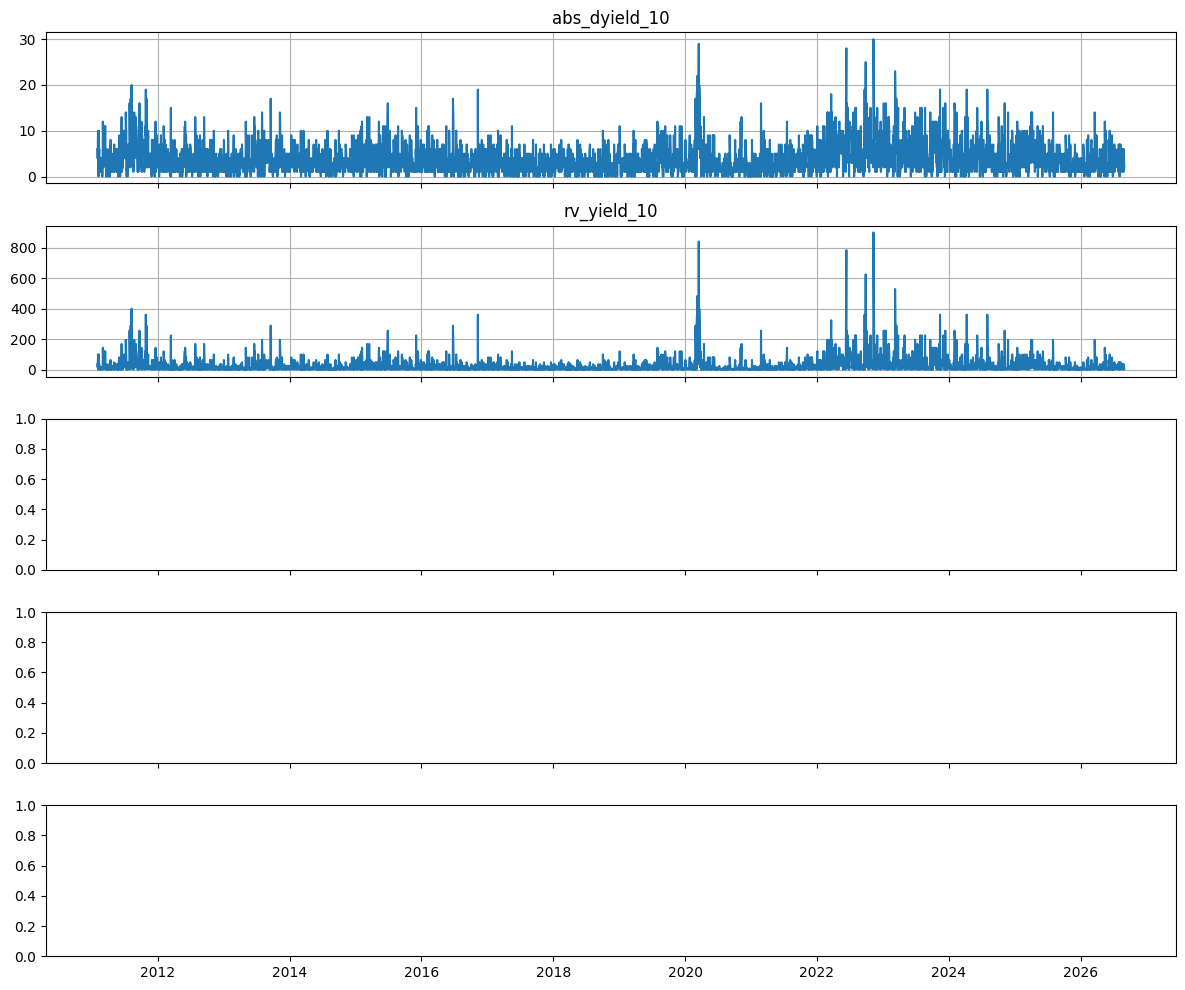

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(12, 10), sharex=True)
columns_to_plot = [col for col in df.columns if "yield" in col]

for i, col in enumerate(columns_to_plot):
    axes[i].plot(df[col])
    axes[i].set_title(col)
    axes[i].grid(True)

plt.tight_layout()
plt.show()

In [22]:
def fit_har_x(
    df_wide,
    target="ES",
    exog_symbols=None,
    extra_exog=None,
    metric="log_rv5",
    include_exog_horizons=False,
    include_extra_horizons=False,
    include_leverage=False,
    hac_lags=22,
    do_forecast=False,    # NEW: Toggle out-of-sample evaluation
    train_split=0.8       # NEW: Split threshold (80% train / 20% test)
):
    """Fits an OLS HAR/LHAR model. If do_forecast=True, executes an expanding window out-of-sample forecast."""
    if exog_symbols is None:
        exog_symbols = []
    if extra_exog is None:
        extra_exog = []

    # 1. Target: tomorrow's realized volatility (t+1)
    y_target = df_wide[f"{metric}_{target}"].shift(-1)

    # 2. Endogenous HAR components for target asset (at day t)
    X_dict = {
        f"{target}_d": df_wide[f"{metric}_{target}"],
        f"{target}_w": df_wide[f"{metric}_w_{target}"],
        f"{target}_m": df_wide[f"{metric}_m_{target}"],
    }

    # 3. Leverage components (Corsi & Reno)
    if include_leverage:
        ret = df_wide[f"ret_{target}"] / 100.0
        ret_w = ret.rolling(5).mean()
        ret_m = ret.rolling(22).mean()

        X_dict[f"{target}_down_d"] = np.abs(np.minimum(ret, 0.0))
        X_dict[f"{target}_down_w"] = np.abs(np.minimum(ret_w, 0.0))
        X_dict[f"{target}_down_m"] = np.abs(np.minimum(ret_m, 0.0))

    # 4. Standard Exogenous Regressors (Commodities)
    for sym in exog_symbols:
        if include_exog_horizons:
            X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]
            X_dict[f"{sym}_w"] = df_wide[f"{metric}_w_{sym}"]
            X_dict[f"{sym}_m"] = df_wide[f"{metric}_m_{sym}"]
        else:
            X_dict[f"{sym}_d"] = df_wide[f"{metric}_{sym}"]

    # 4b. Extra Exogenous Columns (Yield Volatility)
    for col in extra_exog:
        series = df_wide[col]
        if include_extra_horizons:
            X_dict[f"{col}_d"] = series
            X_dict[f"{col}_w"] = series.rolling(5).mean()
            X_dict[f"{col}_m"] = series.rolling(22).mean()
        else:
            X_dict[f"{col}_d"] = series

    # 5. Construct design matrix & align sample
    design_df = pd.DataFrame(X_dict)
    design_df["target_t1"] = y_target
    design_df = design_df.dropna()

    y = design_df["target_t1"]
    X = sm.add_constant(design_df.drop(columns=["target_t1"]))

    # ---------------------------------------------------------
    # 6. Out-of-Sample Forecasting Logic
    # ---------------------------------------------------------
    if do_forecast:
        n_obs = len(X)
        train_size = int(n_obs * train_split) # First 80% for initial training

        predictions = []
        actuals = []
        forecast_dates = []

        # Expanding window loop: evaluates the final 20%
        for t in range(train_size, n_obs):
            # Expanding window training set (grows by 1 each step)
            X_train = X.iloc[:t]
            y_train = y.iloc[:t]

            # One step ahead test row
            X_test = X.iloc[t:t+1]
            y_actual = y.iloc[t]

            # Coefficients re-estimated before every forecast
            model = sm.OLS(y_train, X_train)
            res = model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})

            # Predict
            pred = res.predict(X_test).values[0]

            predictions.append(pred)
            actuals.append(y_actual)
            forecast_dates.append(X.index[t])

        # Error metrics calculation
        mse = mean_squared_error(actuals, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actuals, predictions)

        return {
            "MSE": mse,
            "RMSE": rmse,
            "MAE": mae,
            "predictions": pd.Series(predictions, index=forecast_dates),
            "actuals": pd.Series(actuals, index=forecast_dates)
        }

    # ---------------------------------------------------------
    # 7. Standard In-Sample Fit (Original Behavior)
    # ---------------------------------------------------------
    else:
        model = sm.OLS(y, X)
        results = model.fit(cov_type="HAC", cov_kwds={"maxlags": hac_lags})
        return results

In [20]:
# HELPER FUNCTION: COMBINE IN-SAMPLE & OUT-OF-SAMPLE METRICS
# ------------------------------------------------------------------
def evaluate_model(
    df_wide,
    exog_symbols=None,
    extra_exog=None,
    include_exog_horizons=False,
    include_extra_horizons=False,
    include_leverage=False,
):
    """Executes both full-sample estimation and out-of-sample forecasting."""

    # 1. Full Sample (In-Sample) Fit for AIC, BIC, R²
    m_in = fit_har_x(
        df_wide, target="ES", exog_symbols=exog_symbols, extra_exog=extra_exog,
        include_exog_horizons=include_exog_horizons, include_extra_horizons=include_extra_horizons,
        include_leverage=include_leverage, do_forecast=False
    )

    # 2. Expanding Window (Out-of-Sample) Forecast for Error Metrics
    m_out = fit_har_x(
        df_wide, target="ES", exog_symbols=exog_symbols, extra_exog=extra_exog,
        include_exog_horizons=include_exog_horizons, include_extra_horizons=include_extra_horizons,
        include_leverage=include_leverage, do_forecast=True
    )

    # 3. Compile all requested metrics into a single dictionary
    return {
        "R²": m_in.rsquared,
        "Adj. R²": m_in.rsquared_adj,
        "AIC": m_in.aic,
        "BIC": m_in.bic,
        "Log-Likelihood": m_in.llf,
        "MSE": m_out["MSE"],
        "RMSE": m_out["RMSE"],
        "MAE": m_out["MAE"],
    }


# ------------------------------------------------------------------
# PART 1: EXPANDED COMMODITY SPECIFICATIONS (HAR & LHAR)
#         (Baseline -> Single Exog -> Combinations: 2, 3, and 4)
# ------------------------------------------------------------------
print("Estimating models & running expanding window forecasts... (This will take a moment)")

# Standard HAR Family (include_leverage=False)
model_har_base = evaluate_model(df, include_leverage=False)
model_har_oil = evaluate_model(
    df, exog_symbols=["CL"], include_exog_horizons=True, include_leverage=False
)
model_har_ng = evaluate_model(
    df, exog_symbols=["NG"], include_exog_horizons=True, include_leverage=False
)
model_har_gold = evaluate_model(
    df, exog_symbols=["GC"], include_exog_horizons=True, include_leverage=False
)
model_har_corn = evaluate_model(
    df, exog_symbols=["C"], include_exog_horizons=True, include_leverage=False
)
model_har_energy = evaluate_model(
    df, exog_symbols=["CL", "NG"], include_exog_horizons=True, include_leverage=False
)
model_har_3comm = evaluate_model(
    df, exog_symbols=["CL", "NG", "GC"], include_exog_horizons=True, include_leverage=False
)
model_har_4comm = evaluate_model(
    df, exog_symbols=["CL", "NG", "GC", "C"], include_exog_horizons=True, include_leverage=False
)

# Leverage LHAR Family (include_leverage=True)
model_lhar_base = evaluate_model(df, include_leverage=True)
model_lhar_oil = evaluate_model(
    df, exog_symbols=["CL"], include_exog_horizons=True, include_leverage=True
)
model_lhar_ng = evaluate_model(
    df, exog_symbols=["NG"], include_exog_horizons=True, include_leverage=True
)
model_lhar_gold = evaluate_model(
    df, exog_symbols=["GC"], include_exog_horizons=True, include_leverage=True
)
model_lhar_corn = evaluate_model(
    df, exog_symbols=["C"], include_exog_horizons=True, include_leverage=True
)
model_lhar_energy = evaluate_model(
    df, exog_symbols=["CL", "NG"], include_exog_horizons=True, include_leverage=True
)
model_lhar_3comm = evaluate_model(
    df, exog_symbols=["CL", "NG", "GC"], include_exog_horizons=True, include_leverage=True
)
model_lhar_4comm = evaluate_model(
    df, exog_symbols=["CL", "NG", "GC", "C"], include_exog_horizons=True, include_leverage=True
)

models_part1 = {
    "Baseline HAR": model_har_base,
    "HAR-X (Oil)": model_har_oil,
    "HAR-X (NatGas)": model_har_ng,
    "HAR-X (Gold)": model_har_gold,
    "HAR-X (Corn)": model_har_corn,
    "HAR-X (Energy: Oil + NG)": model_har_energy,
    "HAR-X (3 Comms: CL, NG, GC)": model_har_3comm,
    "HAR-X (4 Comms: CL, NG, GC, C)": model_har_4comm,
    "Baseline LHAR": model_lhar_base,
    "LHAR-X (Oil)": model_lhar_oil,
    "LHAR-X (NatGas)": model_lhar_ng,
    "LHAR-X (Gold)": model_lhar_gold,
    "LHAR-X (Corn)": model_lhar_corn,
    "LHAR-X (Energy: Oil + NG)": model_lhar_energy,
    "LHAR-X (3 Comms: CL, NG, GC)": model_lhar_3comm,
    "LHAR-X (4 Comms: CL, NG, GC, C)": model_lhar_4comm,
}

# Convert the dictionary of metrics directly into a DataFrame
table_part1 = pd.DataFrame.from_dict(models_part1, orient="index")

print("\n" + "=" * 100)
print("PART 1: COMMODITY EXPANSION (IN-SAMPLE & OUT-OF-SAMPLE)")
print("=" * 100)
print(table_part1.round(4))


# ------------------------------------------------------------------
# PART 2: LHAR YIELD VOL SPECIFICATION (SQUARED VS. ABSOLUTE)
#         (3 COMMODITIES vs. 4 COMMODITIES HEAD-TO-HEAD)
# ------------------------------------------------------------------
print(
    "\nRunning Part 2 (3 Comms vs 4 Comms x Squared vs Absolute Yields)..."
)

# 1. Models with 3 Commodities (CL, NG, GC)
m_lhar_3c_rv = evaluate_model(
    df,
    exog_symbols=["CL", "NG", "GC"],
    extra_exog=["rv_yield_10"],
    include_exog_horizons=True,
    include_extra_horizons=False,  # Enforces 1-day yield change
    include_leverage=True,
)

m_lhar_3c_abs = evaluate_model(
    df,
    exog_symbols=["CL", "NG", "GC"],
    extra_exog=["abs_dyield_10"],
    include_exog_horizons=True,
    include_extra_horizons=False,  # Enforces 1-day yield change
    include_leverage=True,
)

# 2. Models with 4 Commodities (CL, NG, GC, C)
m_lhar_4c_rv = evaluate_model(
    df,
    exog_symbols=["CL", "NG", "GC", "C"],
    extra_exog=["rv_yield_10"],
    include_exog_horizons=True,
    include_extra_horizons=False,  # Enforces 1-day yield change
    include_leverage=True,
)

m_lhar_4c_abs = evaluate_model(
    df,
    exog_symbols=["CL", "NG", "GC", "C"],
    extra_exog=["abs_dyield_10"],
    include_exog_horizons=True,
    include_extra_horizons=False,  # Enforces 1-day yield change
    include_leverage=True,
)

models_part2 = {
    # 3 Commodities Bundle
    "LHAR (3 Comms: CL, NG, GC) + Yield Squared": m_lhar_3c_rv,
    "LHAR (3 Comms: CL, NG, GC) + Yield Absolute": m_lhar_3c_abs,
    # 4 Commodities Bundle (including Corn)
    "LHAR (4 Comms: CL, NG, GC, C) + Yield Squared": m_lhar_4c_rv,
    "LHAR (4 Comms: CL, NG, GC, C) + Yield Absolute": m_lhar_4c_abs,
}

table_part2 = pd.DataFrame.from_dict(models_part2, orient="index")

print("\n" + "=" * 100)
print(
    "PART 2: LHAR YIELD VOL SPECIFICATION (3 VS 4 COMMODITIES | SQUARED VS"
    " ABSOLUTE)"
)
print("=" * 100)
print(table_part2.round(4))

Estimating models & running expanding window forecasts... (This will take a moment)

PART 1: COMMODITY EXPANSION (IN-SAMPLE & OUT-OF-SAMPLE)
                                     R²  Adj. R²        AIC        BIC  \
Baseline HAR                     0.7192   0.7190  6062.9689  6087.8933   
HAR-X (Oil)                      0.7197   0.7193  6061.9064  6105.5242   
HAR-X (NatGas)                   0.7197   0.7192  6062.4583  6106.0760   
HAR-X (Gold)                     0.7198   0.7194  6060.3755  6103.9933   
HAR-X (Corn)                     0.7193   0.7188  6067.7493  6111.3670   
HAR-X (Energy: Oil + NG)         0.7202   0.7196  6060.9951  6123.3062   
HAR-X (3 Comms: CL, NG, GC)      0.7211   0.7202  6055.5151  6136.5195   
HAR-X (4 Comms: CL, NG, GC, C)   0.7211   0.7200  6060.9233  6160.6211   
Baseline LHAR                    0.7456   0.7452  5681.8022  5725.3808   
LHAR-X (Oil)                     0.7461   0.7455  5680.6566  5742.9117   
LHAR-X (NatGas)                  0.7467   0.7

In [23]:
# 1. Baseline LHAR for reference
model_lhar_baseline = fit_har_x(df, target="ES", include_leverage=True)

# 2. WITH CORN (All 4 Commodities: CL, C, GC, NG)
# (a) Full multi-horizon (Daily, Weekly, Monthly)
model_lhar_all_full = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C", "GC", "NG"],
    extra_exog=None,
    include_exog_horizons=True,
    include_leverage=True,
)
# (b) Daily-only (No Weekly or Monthly commodity RV)
model_lhar_all_daily = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "C", "GC", "NG"],
    extra_exog=None,
    include_exog_horizons=False,
    include_leverage=True,
)

# 3. WITHOUT CORN (Energy & Gold: CL, NG, GC)
# (a) Full multi-horizon (Daily, Weekly, Monthly)
model_lhar_nocorn_full = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG", "GC"],
    extra_exog=None,
    include_exog_horizons=True,
    include_leverage=True,
)
# (b) Daily-only (No Weekly or Monthly commodity RV)
model_lhar_nocorn_daily = fit_har_x(
    df,
    target="ES",
    exog_symbols=["CL", "NG", "GC"],
    extra_exog=None,
    include_exog_horizons=False,
    include_leverage=True,
)

# ------------------------------------------------------------------
# 4. Compile Comparison Dictionary & Build Summary Table
# ------------------------------------------------------------------
lhar_matrix_models = {
    "Baseline LHAR (including Full d,w,m)": model_lhar_baseline,
    "LHAR-X (All 4 + Full d,w,m)": model_lhar_all_full,
    "LHAR-X (All 4 + Daily Only)": model_lhar_all_daily,
    "LHAR-X (No Corn + Full d,w,m)": model_lhar_nocorn_full,
    "LHAR-X (No Corn + Daily Only)": model_lhar_nocorn_daily,
}

summary_lhar_comparison = pd.DataFrame(
    {
        "Params (k)": [int(m.df_model + 1) for m in lhar_matrix_models.values()],
        "R²": [m.rsquared for m in lhar_matrix_models.values()],
        "Adj. R²": [m.rsquared_adj for m in lhar_matrix_models.values()],
        "AIC": [m.aic for m in lhar_matrix_models.values()],
        "BIC": [m.bic for m in lhar_matrix_models.values()],
        "F-Stat": [m.fvalue for m in lhar_matrix_models.values()],
        "Log-Likelihood": [m.llf for m in lhar_matrix_models.values()],
    },
    index=lhar_matrix_models.keys(),
)

print(summary_lhar_comparison.round(4))

                                      Params (k)      R²  Adj. R²        AIC  \
Baseline LHAR (including Full d,w,m)           7  0.7456   0.7452  5681.8022   
LHAR-X (All 4 + Full d,w,m)                   19  0.7480   0.7468  5670.2718   
LHAR-X (All 4 + Daily Only)                   11  0.7463   0.7456  5679.0536   
LHAR-X (No Corn + Full d,w,m)                 16  0.7479   0.7469  5665.8145   
LHAR-X (No Corn + Daily Only)                 10  0.7463   0.7457  5677.5521   

                                            BIC     F-Stat  Log-Likelihood  
Baseline LHAR (including Full d,w,m)  5725.3808  2130.0370      -2833.9011  
LHAR-X (All 4 + Full d,w,m)           5788.5564   745.9976      -2816.1359  
LHAR-X (All 4 + Daily Only)           5747.5342  1313.3713      -2828.5268  
LHAR-X (No Corn + Full d,w,m)         5765.4226   893.7801      -2816.9073  
LHAR-X (No Corn + Daily Only)         5739.8071  1442.0869      -2828.7761  


In [ ]:
m_lhar_3c_abs.summary()

In [ ]:
def plot_har_residual_diagnostics(
    model_results, date_index=None, model_name="HAR-RV (ES)", lags=20, bins=70
):
    """Plots a 4-panel residual diagnostic grid for an OLS/HAR regression model."""
    # 1. Extract 1D residual series
    resid = model_results.resid

    # Attach proper date index if supplied (dropped last row due to t+1 forecast)
    if date_index is not None:
        resid = pd.Series(resid.values, index=date_index[: len(resid)])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # --- Panel 1: Residuals Over Time ---
    axes[0, 0].plot(
        resid.index, resid.values, color="#1f77b4", lw=0.8, alpha=0.85
    )
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
    axes[0, 0].set_title(
        f"Residuals Over Time: {model_name}", fontweight="bold"
    )
    axes[0, 0].set_ylabel("Residual")
    axes[0, 0].grid(True, alpha=0.3)

    # --- Panel 2: Density vs Theoretical Normal ---
    axes[0, 1].hist(
        resid, bins=bins, density=True, alpha=0.55, color="#2ca02c", edgecolor="none"
    )
    mu, std = stats.norm.fit(resid)
    xmin, xmax = axes[0, 1].get_xlim()
    x_pdf = np.linspace(xmin, xmax, 500)
    kurt = stats.kurtosis(resid, fisher=False)  # Pearson kurtosis (Normal = 3.0)
    skew = stats.skew(resid)

    axes[0, 1].plot(
        x_pdf,
        stats.norm.pdf(x_pdf, mu, std),
        "r--",
        lw=2,
        label=rf"Normal ($\mu={mu:.3f},\ \sigma={std:.3f}$)",
    )
    axes[0, 1].set_title(
        f"Empirical vs. Normal (Kurtosis: {kurt:.1f}, Skew: {skew:.2f})",
        fontweight="bold",
    )
    axes[0, 1].set_ylabel("Density")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # --- Panel 3: Q-Q Plot (Heavy Tails) ---
    sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
    axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)", fontweight="bold")
    axes[1, 0].grid(True, alpha=0.3)

    # --- Panel 4: Autocorrelation Function (ACF) ---
    sm.graphics.tsa.plot_acf(resid, lags=lags, ax=axes[1, 1], alpha=0.05)
    axes[1, 1].set_title(
        f"Residual ACF (Up to {lags} Lags)", fontweight="bold"
    )
    axes[1, 1].set_xlabel("Lag")
    axes[1, 1].set_ylabel("Autocorrelation")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_har_residual_diagnostics(
    model_lhar_nocorn_full, date_index=df.index[:-1], model_name="LHAR all exept corn"
)